

# 👁️‍🗨️ From Visualization to Calculation: Applying the Cost of Carry Model ⚖️

<br>


<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Derivatives-Futures-Chapter-Two/blob/master/colab/Colab_pricing.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Derivatives-Futures-Chapter-Two/master?urlpath=lab/tree/notebooks/pricing.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>

  <a href="https://patrickjhess.github.io/Derivatives-Futures-Chapter-Two/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>

</div>

In the previous notebook, we looked at the historical basis of S&P futures, crude oil, and corn from 30,000 feet. The visual contrast was clear. But looking at graphs is only the first step. The underlying concepts make intuitive sense, but now it is time to move from intuition to application and actually build the pricing machinery.

Let's step back for a moment and imagine an agreement to buy and sell a single share of stock at a future date—not a standardized futures contract, but a simple forward contract. Because both the buyer and seller have the option to just transact today, the forward contract must be at least as economically attractive as buying or selling on the spot market.

If the stock doesn't pay any dividends before the forward agreement expires, the seller receives no benefit from owning the stock beforehand, and the buyer doesn't suffer the loss of missing future dividends. Because the payment is delayed, the forward contract is effectively a financing agreement. The forward price has to compensate the seller for the interest they could have earned if they had sold today and banked the cash. Therefore, the forward price equals the stock price grossed up by the interest rate..

$$Forward\ Price_{t,t+1} = Stock\ Price_t\times (1 +i_{t,t+1})$$

Where $t$ is the current period and the expiration is $t+1$. The interest rate for the period is $i_{t,t+1}$


Any dividends paid during the contract benefit the seller at the expense of the buyer. To keep the trade fair, the forward price has to be decreased by their future value at the time the contract expires.

$$\text{Forward Price}_{t,t+1} = [\text{Stock Price}_t\times (1 +i_{t,t+1})]-\text{FV(DIV}_{t,t+1})$$

Where $\text{FV(DIV}_{t,t+1})$ is the future value of any dividends paid between $t$ and $t+1$.


Let's pivot to a futures contract. Absent the dividends, the buyer (the long position) gets the benefit of owning the stock without putting up money for the period. The seller (the short position), assuming they already own the underlying stock, has converted the risky stock position into a safe asset.

Here we have identified the cost of carry cited in the previous notebook. We presented that formula as:

$$F= S + \text{Storage} - \text{Convenience or Dividend Yield} + \text{Interest}$$


For an equity index:

* **The cost of storage 📦:** is zero.  
* **Dividend yield 💵:** is greater than or equal to zero.  
* **Convenience yield 🤝:** is zero.  
* **Interest 🏦:** is greater than or equal to the applicable SOFR rate.

On paper, this is just simple algebra. In practice? Pinning down the exact timing of dividends, matching the calendar days, and perfectly aligning the interest rate is difficult. Ultimately, building this out will reveal a persistent gap between the theoretical SOFR rate and the actual implied repo rate traded by the market.

<details>
<summary><b style="font-size:1.2em; color: #1976d2;">⚡🔌 Notebook Setup: Why the "Try/Except" Imports?</b></summary>
<br>

<p><b>The Goal:</b><br>
To ensure this notebook runs perfectly whether you are using <b>Google Colab</b>, a local <b>Jupyter instance</b>, or a remote server without you having to manually install software.</p>

<ul>
  <li><b>External Libraries:</b> NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.</li>
  <li><b>The <code>try/except</code> Logic:</b> This is a safety net.
    <ol>
      <li>We <b>try</b> to import the library.</li>
      <li>If it fails (because it's not installed), the <b>except</b> block triggers a <code>%pip install</code> to download it automatically.</li>
    </ol>
  </li>
  <li><b>Aliasing (<code>as np</code>):</b> We rename <code>numpy</code> to <code>np</code> to save keystrokes. In professional finance code, <code>np</code> and <code>pd</code> are the universal shorthand.</li>
</ul>
</details>

## 🛠️ Preparing the Notebook


<details>
<summary><b>👉 Click to Expand: 📦 Importing Libraries, Modules, and Functions</b></summary>
As a best practice, we always begin by importing our necessary dependencies in the very first code cell. Notice how lightweight our imports are here: just the built-in `request` module and the `pandas` and `numpy` libraries. ✨

This simplicity is a direct result of using the `financial_quant` package, which handles the heavy lifting behind the scenes. 🏗️ By keeping complicated setup details out of sight, we ensure the spotlight remains focused exactly where it belongs—on the core analysis. 🎯

```python
try:
    import numpy as np
except:
    %pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd
```
**👀 Keep an eye out**: As we progress, pay attention to how the `financial_quant` package is imported as `fq`, and how every reference to its functions begins with fq.. 💡 This follows the exact same standard practice as NumPy (np) and Pandas (pd).
</details>

In [ ]:
try:
    import numpy as np
except:
    %pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd

## 📦 Getting Functions from financial_quant package

<details>
<summary><b style="font-size:1.2em; color: #1976d2; cursor: pointer;"><span style="font-size: 1.4em;">⚡🔌</span> Professional Packaging: How GitHub Installations Work</b></summary>
<br>
<p><b>The Logic:</b><br>
Usually, Python looks for modules as <code>.py</code> files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.</p>

<p><b>The Workflow:</b></p>
<ol>
<li><b>Fetch & Build:</b> The <code>%pip install git+https://...</code> command tells your Jupyter environment to clone the repository from GitHub and install the <code>financial_quant</code> package directly into your system's site-packages directory.</li>
<li><b>Import:</b> <code>import financial_quant as fq</code> loads the package into your notebook's memory and assigns it the quick alias <code>fq</code>.</li>
<li><b>Routing:</b> Behind the scenes, a special file called <code>__init__.py</code> ats as the package's "front door." It automatically gathers complex tools from deeply nested folders (like our fixed-income models and chart visualizers) and serves them up directly to the surface.</li>
<li><b>Execute:</b> You don't have to worry about where the files live. You just type <code>fq.one_y_axis() or fq.calc_ytm()</code>, and Python immediately knows where to route the request.</li>
</ol>

<p><b>Why do this?</b><br>
This is exactly how professional software engineering teams manage and distribute code. It keeps your notebooks incredibly clean, ensures everyone is using the exact same version of the math models, and guarantees your code is 100% portable to any cloud environment</p>
</details>

In [ ]:
# Use Python's built-in urllib to fetch the remote setup script
import urllib.request

# Download, decode, and execute the updater script directly from GitHub
updater_url = "https://raw.githubusercontent.com/PatrickJHess/quant_repo/master/fq_updater.py"
exec(urllib.request.urlopen(updater_url).read().decode('utf-8'))

# Run the installer/updater function and alias the package as 'fq'
fq = import_financial_quant()

✅ 'financial_quant' is up to date (Version 0.0.2).


## 🏦 Measuring the Financing Advantage

The first step is to identify the interest rate used to offset the financing benefit. The baseline is SOFR—the Secured Overnight Financing Rate that applies to "safe" lending in financial markets. While this rate tends to be sticky, it does fluctuate from day to day. To account for this, we will use the three-month SOFR contract highlighted in Chapter One (Data Infrastructure to Market Mechanics) of this Volume.

>⚠️ Heads up: The rate of finance for the S&P 500 is likely to be greater than SOFR. The funding rate of futures contracts is called the implied repo rate—and although SOFR is the repo rate for bonds, it doesn't have to be the exact same rate for stocks. Indeed, we will compare the implied repo rate of the S&P 500 contract to the applicable SOFR rate.

### What SOFR rate do we need?
To calculate the future value at any payment date $t$, we need the forward rate from $t$ until the expiration date $T$. These calculations are made using the 3-Month SOFR futures contract with an expiration date matching the S&P 500 E-mini contract.

>⚠️ The 3-Month SOFR contract month is actually the quarter before the expiration month. A future chapter of this Volume explains why in detail, but for now, just be aware of the discrepancy.

Before the contract calculation period (roughly three months before the final day of the delivery month), the forward rate for the accrued SOFR equals 100 less the settlement price 🗓️.

**The Math Problem:** Once we are inside that 3-month window, the futures settlement price becomes a blend. It embeds the history of the SOFR rate that has already happened, plus the forward rate for the days remaining.

For our calculations, we only want the future. Therefore, we have to strip out the historical rates. We can infer the necessary adjustment by noting that the total rate is just the historical rate multiplied by the forward rate:

$$1 + R^{futures}_{t+n} \times \frac{T-t}{360} = \left(1 + R^{actual}_{t+n} \times \frac{n}{360}\right) \times \left(1 + R^{forward}_{t+n} \times \frac{T-t-n}{360}\right)$$

Where:

* $t$ is the start of the calculation period,
* $T$ is the end of the calculation period,
* $t+n$ is the current time,
* $R^{futures}_{t+n}$ is the accrued SOFR implied by the futures price,
* $R^{actual}_{t+n}$ is the realized accrued SOFR between $t$ and $t+n$,
* $R^{forward}_{t+n}$ is the forward SOFR rate implied by the futures at $t+n$.

Life is made easier by calculating the realized accrued SOFR with the ratio of the SOFR Index at $t+n$ and $t$:

$$1 + R^{actual}_{t+n} \times \frac{n}{360} = \frac{\text{SOFR Index}_{t+n}}{\text{SOFR Index}_{t}}$$

By substituting this index ratio into our first equation, we can rearrange the algebra to solve purely for the forward SOFR rate:

$$R^{forward}_{t+n} = \left( \left(1 + R^{futures}_{t+n} \times \frac{T-t}{360}\right) \times \frac{\text{SOFR Index}_{t}}{\text{SOFR Index}_{t+n}} - 1 \right) \times \frac{360}{T-t-n}$$

We will use this exact formula in our code to infer forward rates from the SOFR futures contract.

[🤔 **Want More Information About the Calculation Of the SOFR Index? Click here for the NY Fed's methodology**](https://www.newyorkfed.org/markets/reference-rates/sofr-averages-and-index)

<details>
<summary>🕵️‍♂️ <b>Interest On Variation Margin: A Sneaky Effect</b></summary>
<blockquote>
When we think about futures, our focus is typically on the asset that the futures are written on. For example, the S&P 500 or Crude Oil are volatile markets, and worrying about interest on margin seems like a tempest in a teapot.

But what about the SOFR contract? Here, futures prices are directly related to changes in interest rates. What happens when rates go up?
* 📈 **The Short** benefits and is able to invest their daily margin gains at a higher interest rate.
* 📉 **The Long** must finance their losses by borrowing at a higher rate (or forgoing higher earnings).

When rates go down?
* 📉 **The Short** loses but is able to finance the loss at a lower interest rate (forgoing less interest).
* 📈 **The Long** benefits but the gains are invested at a lower interest rate.

You may recognize this as **convexity**—a concept discussed in the Chapter <a href="https://patrickjhess.github.io/Volume-Four-Chapter-Four/"><i>Interest Rate Risk: From Static Metrics to Dynamic Simulation</i> 🧮</a>.

Because of this daily settlement dynamic, the SOFR contract isn't "even-steven" relative to the cash market. To correct this unevenness, the futures price has to be <b>lower</b> than that implied by the cash market. In other words, the implied interest rate has to be <i>higher</i>.

<b>How important is this effect?</b>

It depends upon the horizon. Here, we are going to look at S&P 500 contracts that expire within a quarter. For these short horizons, the effect can be safely ignored and is well within the limits of other approximations. In future chapters, we'll take a more detailed look at SOFR and relate it to swaps—where this attention will be warranted.
</blockquote>
</details>



---
### 💻 **From Theory to Code:** 
Let's translate this formula into a reusable, vectorized Python function. By passing our dataset directly into the engine, we can instantly calculate the stripped forward financing rate for every single day in our timeline.
>🐍 **Pandas Tip: Using `.where()` and `.ffill()`**
In the code below, we rely on two powerful Pandas methods to handle our timeline:
* `.where()`: Keeps the original data where a condition is True, and replaces it if it is False. It reads like this:
   `Series.where(Condition to Keep, Value if False)`. If you omit the "Value if False", it defaults to `NaN`. We use this to filter out days with zero time remaining, dodging a fatal divide-by-zero error.
* **`.ffill()` (forward-fill)**: Replaces those `NaN` values with the last valid number in the sequence. We use this to freeze the final forward rate at zero days remaining and drag that last calculated rate forward through the end of the timeline.

<details>
<summary>📝 <b><font size=4>A Small Code Example</font></b></summary>

```python
import pandas as pd

s = pd.Series([1, 2, 3, 4])

# Keep the original values WHERE they are greater than 2, else NaN
result = s.where(s > 2)
print("After .where():\n", result.values)

# Let's show how ffill() works on a different condition:
result_2 = s.where(s <= 2) # Keeps 1 and 2, makes 3 and 4 NaN
print("\nAfter second .where():\n", result_2.values)
print("\nAfter .ffill():\n", result_2.ffill().values)
```
</details>


In [ ]:
# Vectorized function calculating accrued SOFR forward rates
def calc_implied_forward_rate(df, start_date,end_date,
                              price_col='futures_price', sofr_col='sofr_index',):
    """
    Calculates the stripped forward financing rate across an entire DataFrame.
    Assumes the DataFrame has a DatetimeIndex.
    """
    #When does the calculation period start and end
    t_start=pd.Timestamp(start_date)
    t_end=pd.Timestamp(end_date)

    # Calculate the number of days in the calculation period
    total_days = (t_end - t_start).days
    days_remaining = (t_end - df.index).days
    # 2. Implied rate from the futures price
    r_t_plus_n = (100 - df[price_col]) / 100

    # 2. Historical realization ratio (Index_t / Index_t+n)
    sofr_index_t = df.loc[t_start, sofr_col]
    realized_ratio = sofr_index_t / df[sofr_col]

    # 3. Assemble the formula
    term_1 = 1 + (r_t_plus_n * (total_days / 360))
    r_forward = ((term_1 * realized_ratio) - 1) * (360 / days_remaining)
    # Handle the expiration date to avoid division by zero (days_remaining = 0)
    forward = r_forward.where(days_remaining >= 1)
    forward=forward.ffill()
    return forward

## ⚖️ Comparing The Financial Gain Of The S&P 500 Contract To SOFR

Our experiment centers on the September 2026 S&P 500 E-mini contract—the active front-month contract on August 31, 2026. Because the previous June contract settles on the morning of June 18, 2026, we will use that day's market close to start our clock. Our calculation window runs straight from that close until August 31, 2026.

For the data, we source the daily closing prices for the S&P 500 Spot index and the SOFR index directly from FRED. We pull the futures data (the 3-month SOFR and the S&P 500 E-mini) from Massive.



## 🚰 Futures and Spot Prices: A Job For Our Data Pipelines

We will use two custom data pipelines—`FredReader` and `MASSIVEReader`—to pull the necessary data for this notebook. Both are included in the `financial_quant` package that we imported earlier as `fq`.

To divide and conquer the workload, we will instantiate two specific data objects:

* 🏛️ **`fred_data`:** Powered by `FredReader`, this fetches the underlying Spot (cash) prices.
* 🚀 **`massive_data`:** Powered by `MASSIVEReader`, this serves as our primary engine for downloading the daily futures contract data.

In [ ]:
# Instantiate the data pipelines from the financial_quant package
fred_data = fq.FredReader()
massive_data = fq.MASSIVEReader()

📂 Cache anchored at: /home/pat/fred
✅ Key loaded securely from local vault ('.fred_key')
📂 Cache anchored at: /home/pat/massive_data
✅ Key loaded securely from local vault ('.massive')


### 🏗️ Assembling the Dataset
With our pipelines initialized, we can construct our dataset. In the code below, we:

1. **Set the Timeframe:** Define our calculation window from June 18, 2026, to the contract expiration on September 16, 2026.

2. **Fetch the Raw Data:** Use `fred_data` to pull the S&P 500 cash price and the SOFR Index. Next, use `massive_data` to pull the specific September 2026 futures contracts: E-mini S&P 500 (ESU6) and 3-Month SOFR (SR3M6).

3. **Merge and Align:** Combine all three datasets using an inner join. This is a critical step—it automatically drops weekends and mismatched holidays, ensuring we only keep days where all data points are present. (Note: Even though our queried window spans June 19 to September 19, the actual aligned trading days available in the merged set begin on June 23, 2026, and end on September 1, 2026).

4. **Clean and Isolate:** Rename the raw data columns into intuitive labels (Spot, Futures, Forward SOFR) and lock them into a clean, independent DataFrame called `df_forward`.

>💡 **Pandas Pro-Tip:** Notice the `.copy()` at the very end of the code? This creates a brand new DataFrame in memory, which safely prevents Pandas from throwing a pesky `SettingWithCopyWarning` when we append our calculation columns later

In [ ]:
# 1. Set the Timeframe
start_date='2026-06-18'
end_date='2026-09-16'

# 2. Fetch the Raw Data
df_spot_sofr_index=fred_data.get_series(['SP500','SOFRINDEX'],
                                        start_date=start_date,
                                            end_date=end_date)
df_sofr_sep26=massive_data.get_futures_data('SR3M6',
                                            start_date,
                                              end_date)
df_sp500_sep26=massive_data.get_futures_data('ESU6',
                                              start_date,
                                              end_date)

# 3. Merge and Align
df_sofr_sep26.rename(columns={'settlement_price':'SOFR Futures'},inplace=True)
df_sp500_sep26.rename(columns={'settlement_price':'Futures'},inplace=True)
df=pd.concat([df_sp500_sep26,df_sofr_sep26,df_spot_sofr_index],
             axis=1,join='inner').dropna()
start_clean=df.index[0]
end_clean=df.index[-1]
df['Forward SOFR']=calc_implied_forward_rate(df,start_clean,end_clean,
                                        price_col='SOFR Futures',
                                        sofr_col='SOFRINDEX')

# 4. Clean and Isolate
df.rename(columns={'SP500':'Spot'},inplace=True)
market_data=df[['Futures','Spot','Forward SOFR']].copy()
display(market_data.head())
display(market_data.tail())


☁️--- Processing SP500 ---
🕒 Metadata is fresh (0 days old).
⚠️ FRED has no data past 2026-09-03. Adjusted request to match.
✅ Loaded SP500 from local Parquet cache.

☁️--- Processing SOFRINDEX ---
🕒 Metadata is fresh (0 days old).
⚠️ FRED has no data past 2026-09-04. Adjusted request to match.
✅ Loaded SOFRINDEX from local Parquet cache.

🧩 Merging all series into a single DataFrame...
✅ Merge complete!
🚀 Fetching futures data for SR3M6 (1 day)...
📁 Loaded SR3M6 (1_day) from local Parquet cache.
☁️ Downloading SR3M6 (1_day) via API from 2026-06-18 to 2026-06-22...
💾 Merged and saved SR3M6 to Parquet cache. (Total Coverage: 2026-06-18 to 2026-09-04)
🚀 Fetching futures data for ESU6 (1 day)...
📁 Loaded ESU6 (1_day) from local Parquet cache.
⚡ Full cache hit for ESU6 (1_day). Loaded directly from Parquet.


,Futures,Spot,Forward SOFR
2026-06-23,7437.50,7365.46,0.037150
2026-06-24,7428.25,7358.22,0.037134
2026-06-25,7423.25,7357.49,0.037041
2026-06-26,7401.75,7354.02,0.036916
2026-06-29,7500.25,7440.43,0.037019


,Futures,Spot,Forward SOFR
2026-08-28,7722.00,7711.76,0.037178
2026-08-31,7699.00,7686.14,0.037248
2026-09-01,7642.75,7631.47,0.038363
2026-09-02,7676.50,7666.60,0.038333
2026-09-03,7754.75,7747.71,0.038333


>### 💡 **Next Step:** We have successfully isolated the Interest variable for our Cost of Carry model. We now need to account for the Future Value of Dividends.

### 📥 Part 1: Fetching the Realized Dividend Data
The actual ex-dividend dates and amounts were previously downloaded from the S&P 500 Dividend Points Index (Quarterly) page on the S&P Global website. This dataset tracks the total amount of dividends for S&P 500 stocks that went "ex-dividend" on a given trade date. S&P Global describes the index methodology as follows:
>The S&P 500 Dividend Points Index (Quarterly) is reset to zero after the close on the third Friday of the last month of every calendar quarter, to coincide with futures and options expiration. Thus, the index measures the total dividend points of the S&P 500 since the previous reset date.

The downloaded dataset is hosted in our GitHub repository and includes daily data between September 2, 2025, and August 31, 2026. We access this file using the `static_futures_data` function from our `financial_quant package`.

Once loaded, the system automatically saves it to your local cache as a `.parquet` file.

>🔎 **Just To Be Clear: Why We Model in "Points" (Not Dollars)**

>It is natural to look at a dividend of `0.15` and think, *"That is tiny!"* But we have to remember the difference between **Index Points** and **Notional Dollars**.
>The S&P 500 index itself trades in points (e.g., around 7,400). However, a single E-mini futures contract has a **\$50 multiplier**. This means one contract actually controls a massive portfolio of stock:
>*   **Notional Value:** 7,400 points × $50 = **\$370,000**

>Why do we keep our dividends in points instead of dollars? Because of the pricing math.

> **Why keep dividends in points?**
> To find the fair value of a futures contract, we have to subtract the expected dividends directly from the Spot index price. If we tried to subtract a $7.50 cash dividend from a 7,400-point index, the math would break. By keeping the dividend as `0.15` points, we keep all our variables in the exact same mathematical scale.

[🌐 Link To S&P Global Dividend Data](https://www.spglobal.com/spdji/en/indices/equity/sp-500-dividend-points-index-quarterly/#overview)

In [ ]:
dividend_data = fq.static_futures_data("sp_500_dividends")
dividend_data.index=pd.to_datetime(dividend_data.index, format="%m/%d/%Y")
display(dividend_data.head(2))
display(dividend_data.tail(2))

Fetching Parquet data from GitHub (Cache older than 24 hours): sp_500_dividends.parquet


,Total Dividends
Date,
2025-09-02,14.98
2025-09-03,15.10


,Total Dividends
Date,
2026-08-28,13.93
2026-08-31,14.31


### 🔮Part 2: Estimating the Future Value of Expected Dividends

With our historical data in hand and our financing cost ($R^{\text{forward}}$) calculated, we can turn to the final piece of the model: estimating the future value of the dividends.Calculating the exact future value of expected S&P 500 dividends typically requires expensive institutional data feeds. Because those are often inaccessible, we need to thread the needle between free market data and professional-grade accuracy by applying a few sound, simplifying assumptions. To model the future value of dividends for the September 2026 E-mini S&P 500 contract, we use the following framework:

1. **Lock in Realized Ex-Dates** (June 22 – August 31, 2026)
   * **The Assumption:** We assume the market had perfect foresight about daily dividends that have already occurred.
   * We take the dividend points accumulated between the start of the contract cycle (the first trading day after the June 2026 expiration) and our current date of August 31, treating them as exact matches to market expectations.

2. **Forecast the Remaining Ex-Dates** (September 1 – September 18, 2026)
   * **The Assumption:** We can infer the missing days using the CME S&P 500 Quarterly Dividend Index Futures.
   * We take the settlement value of the September 2026 dividend contract on August 31, subtract the already-realized year-to-date points from Step 1, and prorate that residual value evenly across the remaining business days until expiration.

3. **Account for the Pay Date Lag** (Cash Flow Timing)
   * **The Assumption:** A flat 21-day delay between an ex-date and its actual payment.
   * Ex-dates dictate when a dividend is recorded, but the actual cash typically hits the account about three weeks later. We apply a 21-day lag to every single ex-date to find our true cash flow dates.

4. **Time-Weight the Cash Flows** (Gross-Up vs. Discounting)
   * **The Assumption:** We use the forward SOFR rate to adjust every cash flow to our exact September 18 expiration date.
     * **Gross-up:** If our assumed payment date occurs before expiration, the dividend cash is compounded forward to the expiration date.
     * **Discounting:** If our assumed payment date occurs after expiration, the expected dividend is discounted backward to the expiration date.

### 🔬 Defining The Experiment

Defining the Experiment
Our goal is to calculate the implied repo rate for the September 2026 S&P 500 E-mini contract and compare it to the applicable forward rate.

As highlighted above, forecasting these cash flows requires imperfect—but carefully reasoned—approximations of the market's dividend expectations. Using the known, realized ex-date values between June 22, 2026, and August 31, 2026, is the straightforward part.

To complete the curve, we must extrapolate the implied forecast for the remainder of the contract. The remaining forecasted value for September 1 through expiration equals the September dividend futures settlement value minus the dividends already accumulated between June 22 and August 31.

Our first hands-on step will be stitching together these actual ex-date values with the projected values to build a continuous daily dividend curve running right up to the contract expiration date of September 18, 2026.

In [ ]:
actual_data_start='2026-06-22'
actual_data_end='2026-09-02'
experiment_start='2026-06-23'
experiment_end='2026-09-18'
div_futures=massive_data.get_futures_data('SDIU6',actual_data_start,experiment_end)

🚀 Fetching futures data for SDIU6 (1 day)...
📁 Loaded SDIU6 (1_day) from local Parquet cache.
☁️ Downloading SDIU6 (1_day) via API from 2026-09-04 to 2026-09-04...
💾 Merged and saved SDIU6 to Parquet cache. (Total Coverage: 2026-06-17 to 2026-09-05)


In [ ]:
div_futures.tail()

,Symbol,open,high,low,close,transactions,volume,dollar_volume,settlement_price
session_end_date,,,,,,,,,
2026-08-27,SDIU6,20.82,20.82,20.81,20.82,6,34,707.87,20.81
2026-08-28,SDIU6,20.81,20.81,20.80,20.80,3,100,2080.50,20.80
2026-09-01,SDIU6,20.78,20.83,20.78,20.80,5,23,478.40,20.80
2026-09-02,SDIU6,20.84,20.84,20.76,20.76,4,37,769.02,20.80
2026-09-03,SDIU6,20.76,20.76,20.75,20.75,2,75,1556.50,20.76


### 🛑 Data Check: The Missing Monday

Before we stitch our dates together, look closely at the raw data between **Friday, August 28** and **Tuesday, September 1**.

Notice anything missing? There is no row for **Monday, August 31**.

This isn't a glitch in your download; it is a reality of market microstructure. Unlike the standard E-mini S&P 500 futures that trade millions of contracts a day, Dividend Index futures are a niche, institutional product. They are notoriously illiquid. If no buyers or sellers transact during a session, many data providers simply drop the day entirely rather than logging a row with zero volume.

**The Quantitative Lesson:**
In financial modeling, a missing row doesn't mean the contract ceased to exist. It means the market's expectations didn't shift enough to trigger a trade. Therefore, the most mathematically sound way to model **Monday, August 31**, is to assume the market's view remained unchanged from Friday's close.

To fix this, we won't just ignore the missing day. We will intentionally rebuild a complete business calendar and carry Friday's settlement price forward into Monday.

### 🛠️The Fix: Rebuilding the Calendar
We are going to tell Pandas to generate a flawless Monday-through-Friday calendar, map our existing data onto it, and fill any blank spaces with the most recent valid settlement price.

**Safety Tip:** In quantitative modeling, never overwrite your raw data. If you make a mistake and overwrite your original variable, you often have to restart your entire kernel to recover the baseline values. To avoid that trap, we leave `div_futures` intact and save our cleaned, forward-filled timeline into a brand new DataFrame called `div_fill`.

Run the cell below to align the index and carry Friday's price forward into Monday:


In [ ]:
# 1. Clean the index: Use the official session date instead of the server timestamp

div_futures.index = pd.to_datetime(div_futures.index)

print("BEFORE: Notice the jump from Aug 28 to Sep 01")
display(div_futures['settlement_price'].loc['2026-08-28':'2026-09-01'])
print("-" * 40)

# 2. Create a "perfect" business day calendar (Monday-Friday) for our date range
start_date = div_futures.index.min()
end_date = div_futures.index.max()
perfect_calendar = pd.bdate_range(start=start_date, end=end_date)

# 3. Reindex the dataframe to our perfect calendar
# Any missing days (like Aug 31) will initially appear as 'NaN' (Not a Number)
div_fill = div_futures.reindex(perfect_calendar)

# 4. Forward-fill (ffill) the missing values
# This carries Friday's settlement price forward into the empty Monday slot
div_fill = div_fill.ffill()

print("AFTER: August 31 is now populated with August 28's settlement")
display(div_fill['settlement_price'].loc['2026-08-28':'2026-09-01'])

BEFORE: Notice the jump from Aug 28 to Sep 01


,settlement_price
session_end_date,
2026-08-28,20.8
2026-09-01,20.8


----------------------------------------
AFTER: August 31 is now populated with August 28's settlement


,settlement_price
2026-08-28,20.8
2026-08-31,20.8
2026-09-01,20.8


### 🧩 Stitching Together Our Dividend Series

Between June 22 and August 31, 2026, we treat the actual, realized ex-date values as exact matches to market expectations. For the remainder of the contract, we need to extrapolate the remaining expected dividends evenly until expiration (September 18, 2026).

Because the September futures contract forecasts all the dividends paid across the entire quarter, we must subtract the dividends that have already gone ex-dividend (June 22 to August 31) from the futures settlement value to isolate what is left.

Here is our three-step plan to build the final series:

1. **The Total Actual Dividends:** Sum all the realized ex-date dividends between June 22 and August 31, 2026.
2. **The September Dividend Series:** Subtract the Total Actual Dividends from the September 1 futures settlement value to find the residual (remaining) value. We then prorate this residual evenly across each remaining business day up to and including the September 18 expiration.
3. **The Final Experiment Series:** Concatenate (join) the realized daily dividends with the newly forecasted September dividends to create a single, continuous daily series.

<details>
<summary> <font size="4">💡 Intuition Check: The Final Settlement Is Equivalent To "Sell at the Open" </font></summary>

>This is by design. Index futures are cash-settled because it is logistically messy to deliver 500 physical stocks. The AM settlement (the SOQ) is specifically engineered to mimic the exact cash flows an index arbitrageur would get if they liquidated their physical stock portfolio directly into the 9:30 AM NYSE opening auction.

>Because the stock opens "ex-dividend" at 9:30 AM, the opening price is already reduced by the dividend amount. If you sell at the open, you capture the dividend (which pays out weeks later) but take the price drop. The expiring futures contract forces you to absorb that exact same mathematical reality.

</details>

In [ ]:
# 1. Total Actual Dividends
# We sum the dividends accumulated by our end date of August 31, 2026
last_actual_date = '2026-08-31'
total_actual = dividend_data['Total Dividends'].loc[last_actual_date]

# 2. The September Dividend Series
# We use the September 1 futures settlement to represent the market's quarterly forecast
sept_1_forecast = div_fill['settlement_price'].loc['2026-09-01']
sept_dividends_remaining = sept_1_forecast - total_actual

# Create a calendar for the remaining days up to expiration
experiment_end = '2026-09-18'
sept_dates = pd.bdate_range(start='2026-09-01', end=experiment_end)

# Prorate the remaining dividends evenly across these days
if not sept_dates.empty:
    sept_ex_date_dividends = pd.Series(
        sept_dividends_remaining / len(sept_dates),
        index=sept_dates
    )

# 3. The Final Experiment Series
# Use .diff() to convert the cumulative 'Total Dividends' back into daily payouts
ex_date_dividends = dividend_data['Total Dividends'].loc['2026-06-22':'2026-08-31'].diff()

# .diff() makes the first day NaN, so we manually insert the first day's total
ex_date_dividends['2026-06-22'] = dividend_data['Total Dividends'].loc['2026-06-22']

# Concatenate the realized series and the forecasted series into one continuous curve
experiment_dividends = pd.concat([ex_date_dividends, sept_ex_date_dividends]).sort_index()

# Display the final stitched curve
print("First 5 days (Realized):")
display(experiment_dividends.head())
print("\nLast 5 days (Forecasted):")
display(experiment_dividends.tail())

First 5 days (Realized):


,0
2026-06-22,0.43
2026-06-23,0.07
2026-06-24,0.05
2026-06-25,0.34
2026-06-26,0.19



Last 5 days (Forecasted):


,0
2026-09-14,0.463571
2026-09-15,0.463571
2026-09-16,0.463571
2026-09-17,0.463571
2026-09-18,0.463571


### 🗓️ Step 3: Mapping the Timeline to Expiration
Before we can calculate the Future Value of these dividends, we need to know exactly how many days each cash flow must be compounded forward (or discounted backward, if the payment arrives after expiration) to match our September 18 settlement date.

We will build a self-contained Cash Flow Schedule (a DataFrame). This will hold our ex-dates, our 21-day delayed payment dates, and the exact number of days between that payment and expiration.

Run the cell below to build the schedule:

In [ ]:
# 1. Convert our final dividend series into a clean DataFrame
cash_flows = experiment_dividends.reset_index()
cash_flows.columns = ['ex_date', 'dividend_points']

# 2. Apply the 21-day lag to create actual payment dates
cash_flows['pay_date'] = cash_flows['ex_date'] + pd.Timedelta(days=21)

# 3. Calculate Days to Expiration
# We subtract the pay_date from the expiration date.
# Positive numbers = Days to compound forward (paid before expiration)
# Negative numbers = Days to discount backward (paid after expiration)
expiration_date = pd.to_datetime('2026-09-18')
cash_flows['days_to_expiration'] = (expiration_date - cash_flows['pay_date']).dt.days

# 4. Reorder for a clean, chronological view
cash_flows = cash_flows[['ex_date', 'pay_date', 'days_to_expiration', 'dividend_points']]

print("--- Early Dividends (Compounded Forward) ---")
display(cash_flows.head())

print("\n--- Late Dividends (Discounted Backward) ---")
display(cash_flows.tail())

--- Early Dividends (Compounded Forward) ---


,ex_date,pay_date,days_to_expiration,dividend_points
0,2026-06-22,2026-07-13,67,0.43
1,2026-06-23,2026-07-14,66,0.07
2,2026-06-24,2026-07-15,65,0.05
3,2026-06-25,2026-07-16,64,0.34
4,2026-06-26,2026-07-17,63,0.19



--- Late Dividends (Discounted Backward) ---


,ex_date,pay_date,days_to_expiration,dividend_points
59,2026-09-14,2026-10-05,-17,0.463571
60,2026-09-15,2026-10-06,-18,0.463571
61,2026-09-16,2026-10-07,-19,0.463571
62,2026-09-17,2026-10-08,-20,0.463571
63,2026-09-18,2026-10-09,-21,0.463571


### 🧮 Step 4: Calculating the Time-Weighted Future Value

Now that our cash flow schedule is built, we have one final step: determining what those dividends are actually worth on expiration day (September 18, 2026).

To do this accurately, we have to apply standard money market math (Actual/360) based on when the cash is paid:

*   **Paid Before Expiration (Gross-Up):** We use the daily `Forward SOFR` rate corresponding to the ex-date. This rate perfectly matches the timeline from the observation date to expiration.
*   **Paid After Expiration (Discounting):** We cannot use our daily rate here, because the cash flow occurs *after* expiration. Instead, we must apply a single, fixed forward rate that covers the specific post-expiration window (late September to October).

$$Future Value = Dividend \times \left(1 + Rate \times \frac{Days\ to\ Expiration}{360}\right)$$

💡 **A Mathematical Freebie**

>You might be wondering why we don't have a separate division formula for discounting late payments. Because our `days_to_expiration` column explicitly uses negative numbers for cash flows paid after expiration, plugging them into this exact same forward formula automatically handles the backward discounting for us.

>Shouldn't we have divided the cash flow by the interest factor to calculate present value? Yes, technically. But for short-term adjustments, the market standard is a linear discount approximation. To see why this works, look at the first-order Maclaurin series expansion:

$$(1 + r \times \frac{t}{360})^{-1} \simeq 1 - r \times \frac{t}{360}$$

>By allowing $t$ to be negative in our standard formula, we perfectly replicate this first-order approximation: an elegant mathematical shortcut that keeps our code clean and perfectly matches market practice.

### 📉 Step 5: The Daily Dividend Valuation (No Time Traveling!)

To calculate the Implied Repo Rate for *every single trading day* in our dataset, we need the total Future Value of expected dividends for each day.

This requires solving two dynamic problems:
1. **The Shrinking Pool:** As days pass, dividends go "ex-dividend" and drop out of the Spot index. The futures contract no longer prices them in.
2. **The Daily Rate Change:** If we are calculating the contract's fair value on June 22, we must compound all future dividends using **June 22's interest rate**. We cannot use August's interest rate to value an August dividend, because on June 22, the market doesn't know what August's rate will be!

To get this exactly right, we will simulate walking through time. For every trading day, we will look at the remaining dividends and value them using *that specific day's* Forward SOFR rate.

> 🐍 **Python Tip: Translating `np.where`**
> In the code below, we use `np.where()`. This functions similarly to `Series.where()` in Pandas, but with one key difference: NumPy requires you to explicitly supply both the `True` and `False` return values:

>`np.where(Condition, Value if True, Value if False)`

>We use it to route our interest rates: IF the dividend pays before expiration (True), apply today's daily market rate. IF it pays after expiration (False), apply our fixed post-expiration rate.

<details>
<summary><b><font size=4> 📝 A Small Code Example</font></b></summary>

```python
import numpy as np
import pandas as pd

df = pd.DataFrame({'score': [85, 45, 92]})

# Just like Excel Or Google Sheets: =IF(score >= 70, "Pass", "Fail")
df['status'] = np.where(df['score'] >= 70, 'Pass', 'Fail')

print(df)
# Row 0: 85 -> 'Pass'
# Row 1: 45 -> 'Fail'
# Row 2: 92 -> 'Pass'
```
</details>

In [ ]:
import numpy as np
import pandas as pd

# Create an empty dictionary to store our daily totals
daily_fv_totals = {}

# The post-expiration rate we established earlier for late payments
post_exp_forward_rate = market_data['Forward SOFR'].loc['2026-08-31']

# Walk through each day in our market data
for current_date in market_data.index:

    # 1. What is the interest rate TODAY?
    current_rate = market_data.loc[current_date, 'Forward SOFR']

    # 2. What dividends are remaining? (ex_date on or after today)
    remaining_divs = cash_flows[cash_flows['ex_date'] >= current_date].copy()

    if remaining_divs.empty:
        daily_fv_totals[current_date] = 0
        continue

    # 3. Apply the correct rate (Today's rate for early payments, Fixed rate for late payments)
    remaining_divs['applied_rate'] = np.where(
        remaining_divs['days_to_expiration'] >= 0,
        current_rate,
        post_exp_forward_rate
    )

    # 4. Calculate the Future Value of the pool using TODAY'S rate
    # 💡 Notice our mathematical freebie is still at work!
    # Negative days_to_expiration will automatically discount the late payments.
    remaining_divs['fv'] = remaining_divs['dividend_points'] * (
        1 + remaining_divs['applied_rate'] * (remaining_divs['days_to_expiration'] / 360)
    )

    # 5. Sum the total and store it for this specific date
    daily_fv_totals[current_date] = remaining_divs['fv'].sum()

# Add this perfect daily calculation back into our market data
market_data['FV_Dividends'] = pd.Series(daily_fv_totals)

print("--- Daily Expected Future Value of Dividends ---")
display(market_data[['Spot', 'Futures', 'Forward SOFR', 'FV_Dividends']].tail())

--- Daily Expected Future Value of Dividends ---


,Spot,Futures,Forward SOFR,FV_Dividends
2026-08-26,7675.70,7690.00,0.037239,7.160917
2026-08-27,7730.99,7742.50,0.037403,7.120909
2026-08-28,7711.76,7722.00,0.037650,7.100907
2026-08-31,7686.14,7699.00,0.039350,6.860907
2026-09-01,7631.47,7642.75,0.039350,6.481031


### 🎯 Step 6: Calculating the Implied Repo Rate (IRR)

We have finally assembled all the pieces. For every single trading day, we now have:
1. The **Spot** index price.
2. The **Futures** contract price.
3. The estimated Future Value of all remaining **Dividends**, properly time-weighted using that specific day's interest rate.

With these three variables, we can extract the exact financing rate the market is pricing into the futures contract—the **Implied Repo Rate**. We simply rearrange our standard Cost of Carry formula to solve for the rate:

$$Implied\ Repo = \left( \frac{Futures + FV(Dividends)}{Spot} - 1 \right) \times \frac{360}{Days\ to\ Expiration}$$

>**⚠️ A Quick Heads-Up on Real-World Noise:**
Before we run this calculation, we have to acknowledge that our inputs are a little muddy. There are two major culprits that introduce "noise" into our equation:

>* **The 15-Minute Gap:** The cash S&P 500 index officially closes at 4:00 PM ET, but the E-mini futures contract settles 15 minutes later at 4:15 PM ET. If a major news story breaks at 4:05 PM, the futures price will move to reflect it, while the spot price remains frozen. We are mathematically equating prices that were stamped 15 minutes apart!

>* **The Dividend Guessing Game:** Our formula relies on the estimated future value of dividends. While the market is incredibly good at forecasting what companies will pay out over the next few months, it is still an estimate.

>**Annualization Amplifies Approximation Errors:** Notice that final part of the equation—multiplying by 360 / Days to Expiration. This annualization factor acts like a magnifying glass for pricing mismatches or dividend approximations. As expiration approaches and the remaining days shrink toward zero, this multiplier explodes—causing the calculated Implied Repo Rate to look extremely volatile in the final weeks of the contract!

Let's calculate the daily Implied Repo Rates and compare them side-by-side with the actual `Forward SOFR`rate.

In [ ]:
# 1. Calculate the days to expiration for the actual futures contract
expiration_date = pd.to_datetime('2026-09-18')
market_data['days_to_expiration'] = (expiration_date - market_data.index).days

# 🛑 Safety Check: Avoid dividing by zero!
# As we approach expiration day, days_to_expiration hits zero.
# We only calculate IRR for days strictly before expiration.
pricing_days = market_data['days_to_expiration'] > 0

# 2. Calculate the Implied Repo Rate using our formula
market_data.loc[pricing_days, 'Implied Repo Rate'] = (
    (
        (market_data['Futures'] + market_data['FV_Dividends']) / market_data['Spot']
    ) - 1
) * (360 / market_data['days_to_expiration'])

# 3. Clean up the view to compare the Implied Rate vs the Actual Market Rate
final_columns = ['Spot', 'Futures', 'FV_Dividends', 'Forward SOFR', 'Implied Repo Rate']

print("--- Final Implied Repo Rate vs. Foward SOFR ---")
display(market_data.loc[pricing_days, final_columns].dropna().tail())

--- Final Implied Repo Rate vs. Foward SOFR ---


,Spot,Futures,FV_Dividends,Forward SOFR,Implied Repo Rate
2026-08-26,7675.70,7690.00,7.160917,0.037239,0.043763
2026-08-27,7730.99,7742.50,7.120909,0.037403,0.039435
2026-08-28,7711.76,7722.00,7.100907,0.037650,0.038548
2026-08-31,7686.14,7699.00,6.860907,0.039350,0.051316
2026-09-01,7631.47,7642.75,6.481031,0.039350,0.049285


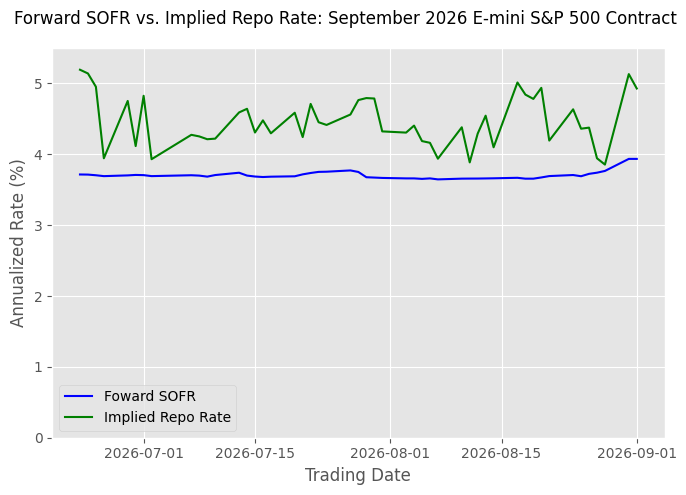

In [ ]:
# 1. Define data to be plotted
plot_data=[market_data['Forward SOFR']*100,
           market_data['Implied Repo Rate']*100]

# 2. Define the series
series=['Forward SOFR',
        'Implied Repo Rate']

# 3. x_axis dates
x_axis=market_data.index

size=(7,5)
markers=['']*2
colors=['b','g']

# use nanmin and nanmax so that nan is ignogred
y_lower=np.nanmin(plot_data)-1
y_upper=np.nanmax(plot_data)+1


ylim=[0,5.5]
title='Forward SOFR vs. Implied Repo Rate: September 2026 E-mini S&P 500 Contract'
xlabel='Trading Date'
ylabel='Annualized Rate (%)'
fq.one_y_axis(x_axis, plot_data, title=title, series_labels=series, xlabel=xlabel,
              y_limits=ylim,ylabel=ylabel, markers=markers,colors=colors,
              figure_size=size)

## 📈 Module: Index Futures Pricing & The Implied Repo Rate

### 🎯 The Core Problem: Beyond the Textbook
If you open any standard finance textbook, you will find a very clean, continuous-time formula for pricing a futures contract:

$$ F = S \times e^{(r-q)T} $$

It implies that to find the Futures price ($F$), you simply take the Spot index price ($S$), add the continuous risk-free interest rate ($r$), and subtract the continuous dividend yield ($q$).

But trading desks don't operate in continuous textbook time. In the real world, the math is messy:
*   **Dividends are lumpy:** They aren't paid as a smooth daily yield. They are discrete cash flows that happen on specific dates.
*   **Rates change daily:** You cannot use a single flat interest rate for the whole year.
*   **Banks charge a premium:** You can't borrow billions of dollars at the exact risk-free rate; prime brokers charge a spread to use their balance sheet.

### 🛠️ What We Built
In this notebook, we abandoned the textbook approximation and built a pricing engine dealimg with the messy details of data availability.

We approximated the **Implied Repo Rate** (financing rate) embedded in the E-mini S&P 500 futures contract.

**Our Journey:**
1.  **Fetched Realized Dividends:** Download the actual, daily S&P 500 Dividend Points Index.
2.  **Mapped the Calendar:** Align these lumpy cash flows with the exact expiration date of the futures contract.
3.  **Applied Money Market Math:** Calculated the precise Future Value of every single dividend using daily Forward SOFR rates.
4.  **Extracted the Implied Rate:** Reverse-engineered the Cost of Carry formula to see what financing spread the market actually charged.

By the end, an illustration of where textbook math ends and market microstructure begins!


### 🕵️‍♂️ Market Reality: Why don't the rates match perfectly?


Welcome to the real world of quantitative finance!

1. **We cheated by using a Crystal Ball:** We used actual, realized dividends in our code. But a trader in July, August, or September of 2026 had to use estimated dividends. If companies ended up paying slightly higher dividends than the market originally forecast, our FV_Dividends variable is larger than the one the market used. Mathematically, this forces our calculated Implied Repo Rate higher.

2. **The Balance Sheet Premium:** Textbook formulas assume you can borrow billions of dollars at the exact risk-free SOFR rate. In reality, arbitrage only happens with the help of Prime Brokers. If the implied repo rate is too high, an arbitrage requires a coincident purchase of the index and shorting the futures. The Prime Broker's balance sheet finances the purchase, holds the collateral, and manages the margin. That's not free.

---
<details>
<summary><font size="4">🏦 A Brief Detour: What Exactly is a Prime Broker?</b></font></summary>
<blockquote>
What "Balance Sheet Premium" are talking about?

If you ask most finance students what a broker does, they will usually describe an Executing Broker—the entity that routes your order to an exchange to buy or sell a security. But for hedge funds and large institutional quantitative desks, execution is the easy part. The real bottleneck is financing.

Enter the Prime Broker (usually a massive investment bank like Goldman Sachs, Morgan Stanley, or JPMorgan). A prime broker acts as the central hub for a hedge fund's operations. They are less of an executing middleman and more of a specialized, high-octane bank.

Here is the difference that matters for our math:

* **Executing Broker:** "You want to buy 500 shares of Apple? I will route that to the NASDAQ for you."

* **Prime Broker:** "You want to execute a $500 million Index Arbitrage trade? I will hold your collateral, clear the futures trades, lend you the cash to buy the underlying stocks, and charge you a daily interest rate for using my bank's balance sheet."

Why this matters?:
When a quantitative hedge fund spots a mispricing between the S&P 500 Spot index and the Futures contract, they need lots of leverage to exploit it. They get that cash from their Prime Broker.

The Prime Broker doesn't lend cash at the pure risk-free SOFR rate. They charge SOFR + a spread. That exact spread—the cost of doing business with a Prime Broker.
</blockquote>
</details>

### 🚀 Looking Ahead: The Balance Sheet Solution (Swap Futures)

We just spent a lot of computational energy backing into the Implied Repo Rate. We discovered that it doesn't perfectly match the pure SOFR rate. Putting our data approximations aside, the spread represents a **Balance Sheet Premium**—what banks charge to finance these trades under strict modern capital regulations.

What if we didn't have to back into this rate? What if we could just trade the financing spread directly?

Enter **S&P 500 Total Return Swap Futures (like the CME's AIR TRF)**.

These contracts were designed to solve exactly the friction we just modeled:
1. **Balance Sheet Relief:** Because they are centrally cleared on an exchange, they consume a fraction of the prime broker capital required for traditional OTC swaps, making financing significantly cheaper.
2. **Trading the Spread:** Instead of quoting a raw index price, TRFs quote the actual financing spread over SOFR (e.g., SOFR + 20 bps). The augmented financing rate *is* the explicit settlement mechanism.
3. **No Dividend Guessing:** They explicitly pass through the exact, realized daily dividends using the same S&P 500 Dividend Points Index we just downloaded.

In our next Chapter, we will put away the dividend estimation formulas and learn how to price and trade these explicit funding spreads!